# 0 IMPORTACIÓN DE BIBLIOTECAS Y LIBRERÍAS

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis, norm
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

# 1 INGESTIÓN O CARGA DE DATOS

In [2]:
df_original = pd.read_csv(r"C:\Users\ingen\OneDrive\Escritorio\CURSO DE DATA SCIENCE\ULTIMO PROYECTO\cathycaz-intro-ml\data\raw\diabetes.csv")

print(f"TAMAÑO DEL DATASET: {df_original.shape[0]} filas x {df_original.shape[1]} columnas")

TAMAÑO DEL DATASET: 768 filas x 9 columnas


# 2 INSPECCIÓN INICIAL

## 2.1 VISUALIZACIÓN DE TODAS LAS COLUMNAS 

In [3]:
pd.set_option('display.max_columns', None)
# Esto sirve para que me muestre todas las columnas cuando un DataSet es muy ancho o con muchas columnas 
# Con el (None) le digo que me muestre todas las columnas sin limitación
df_original.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


## 2.2 INFORMACIÓN DEL DATASET 

In [4]:
# Información general del dataset
print("INFORMACIÓN GENERAL:")
print("="*80)
df_original.info()

print("\n" + "="*80)

# Lista de columnas
print("COLUMNAS DEL DATASET:\n")
print(df_original.columns.tolist())


INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

COLUMNAS DEL DATASET:

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 2.3 CLASIFICACIÓN DE COLUMNAS DEL DATASET PARA DETECTAR NÚMERICAS, CATEGÓRICAS, BOOLEANAS Y DATETIME

In [5]:
numerical_cols = df_original.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\n" + "="*80)
print("COLUMNAS NUMÉRICAS:\n")
print(numerical_cols)
print(f"Cantidad de Columnas Numéricas: {len(numerical_cols)}")

categorical_cols = df_original.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n" + "="*80)
print("COLUMNAS CATEGÓRICAS:\n")
print(categorical_cols)
print(f"Cantidad de Columnas Categóricas: {len(categorical_cols)}")

boolean_cols = df_original.select_dtypes(include=['bool']).columns.tolist()
print("\n" + "="*80)    
print("COLUMNAS BOOLEANAS:\n")
print(boolean_cols)
print(f"Cantidad de Columnas Booleanas: {len(boolean_cols)}")

datetime_cols = df_original.select_dtypes(include=['datetime64']).columns.tolist()
print("\n" + "="*80)    
print("COLUMNAS DE FECHA Y HORA:\n")
print(datetime_cols)
print(f"Cantidad de Columnas de Fecha y Hora: {len(datetime_cols)}")


COLUMNAS NUMÉRICAS:

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Cantidad de Columnas Numéricas: 9

COLUMNAS CATEGÓRICAS:

[]
Cantidad de Columnas Categóricas: 0

COLUMNAS BOOLEANAS:

[]
Cantidad de Columnas Booleanas: 0

COLUMNAS DE FECHA Y HORA:

[]
Cantidad de Columnas de Fecha y Hora: 0


## 2.4 DESCRIPCIÓN GENERAL DEL DATASET

In [6]:
df_original.describe(include='all').T # Include all sirve para que me muestre todas las estadísticas de todas las variables, incluyendo las categóricas

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2.5 ANÁLISIS DE DISTRIBUCCIÓN PARA COLUMNAS NÚMERICAS

In [7]:
numerical_cols = df_original.select_dtypes(include=['int64', 'float64']).columns

# Crear DataFrame con estadísticas de distribución
dist_stats = pd.DataFrame({
    'Variable': numerical_cols,
    'Media': [df_original[col].mean() for col in numerical_cols],
    'Mediana': [df_original[col].median() for col in numerical_cols],
    'Desv_Std': [df_original[col].std() for col in numerical_cols],
    'Skewness': [skew(df_original[col].dropna()) for col in numerical_cols],
    'Kurtosis': [kurtosis(df_original[col].dropna()) for col in numerical_cols]
})

# Determinar tipo de distribución
def clasificar_distribucion(skew_val, kurt_val):
    # Clasificar por skewness 
    # ¿Hacia dónde se inclina?
    if abs(skew_val) < 0.5:
        tipo_skew = "Simétrica"
    elif skew_val > 0.5:
        tipo_skew = "Asimétrica +"
    else:
        tipo_skew = "Asimétrica -"
    
    # Clasificar por kurtosis
    # ¿Qué tan puntiaguda es? 
    # La kurtosis mayor a 1 es la que me indica cuantos outliers tengo 
    # mientras mas se aleja de 1 mayor atención debo prestar a esa variable
    if kurt_val > 1:
        tipo_kurt = "Leptocúrtica"
    elif kurt_val < -1:
        tipo_kurt = "Platicúrtica"
    else:
        tipo_kurt = "Mesocúrtica"
    
    return f"{tipo_skew} | {tipo_kurt}"

dist_stats['Tipo_Distribución'] = dist_stats.apply(
    lambda row: clasificar_distribucion(row['Skewness'], row['Kurtosis']), axis=1
)

# Redondear valores para mejor visualización
dist_stats = dist_stats.round(3)

print("=" * 100)
print("ANÁLISIS DE DISTRIBUCIÓN POR VARIABLE")
print("=" * 100)
print("\nGuía de Interpretación:")
print("  • Skewness: |valor| < 0.5 (Simétrica), > 0.5 (Asimétrica +), < -0.5 (Asimétrica -)")
print("  • Kurtosis: > 1 (Leptocúrtica/Puntiaguda), < -1 (Platicúrtica/Achatada), entre -1 y 1 (Mesocúrtica/Normal)")
print("\n")

dist_stats

ANÁLISIS DE DISTRIBUCIÓN POR VARIABLE

Guía de Interpretación:
  • Skewness: |valor| < 0.5 (Simétrica), > 0.5 (Asimétrica +), < -0.5 (Asimétrica -)
  • Kurtosis: > 1 (Leptocúrtica/Puntiaguda), < -1 (Platicúrtica/Achatada), entre -1 y 1 (Mesocúrtica/Normal)




,Variable,Media,Mediana,Desv_Std,Skewness,Kurtosis,Tipo_Distribución
0,Pregnancies,3.845,3.000,3.370,0.900,0.150,Asimétrica + | Mesocúrtica
1,Glucose,120.895,117.000,31.973,0.173,0.629,Simétrica | Mesocúrtica
2,BloodPressure,69.105,72.000,19.356,-1.840,5.139,Asimétrica - | Leptocúrtica
3,SkinThickness,20.536,23.000,15.952,0.109,-0.524,Simétrica | Mesocúrtica
4,Insulin,79.799,30.500,115.244,2.268,7.160,Asimétrica + | Leptocúrtica
5,BMI,31.993,32.000,7.884,-0.428,3.261,Simétrica | Leptocúrtica
6,DiabetesPedigreeFunction,0.472,0.372,0.331,1.916,5.551,Asimétrica + | Leptocúrtica
7,Age,33.241,29.000,11.760,1.127,0.631,Asimétrica + | Mesocúrtica
8,Outcome,0.349,0.000,0.477,0.634,-1.598,Asimétrica + | Platicúrtica


## 2.6 HISTOGRAMA DE DISTRIBUCCIÓN PARA COLUMNAS NÚMERICAS

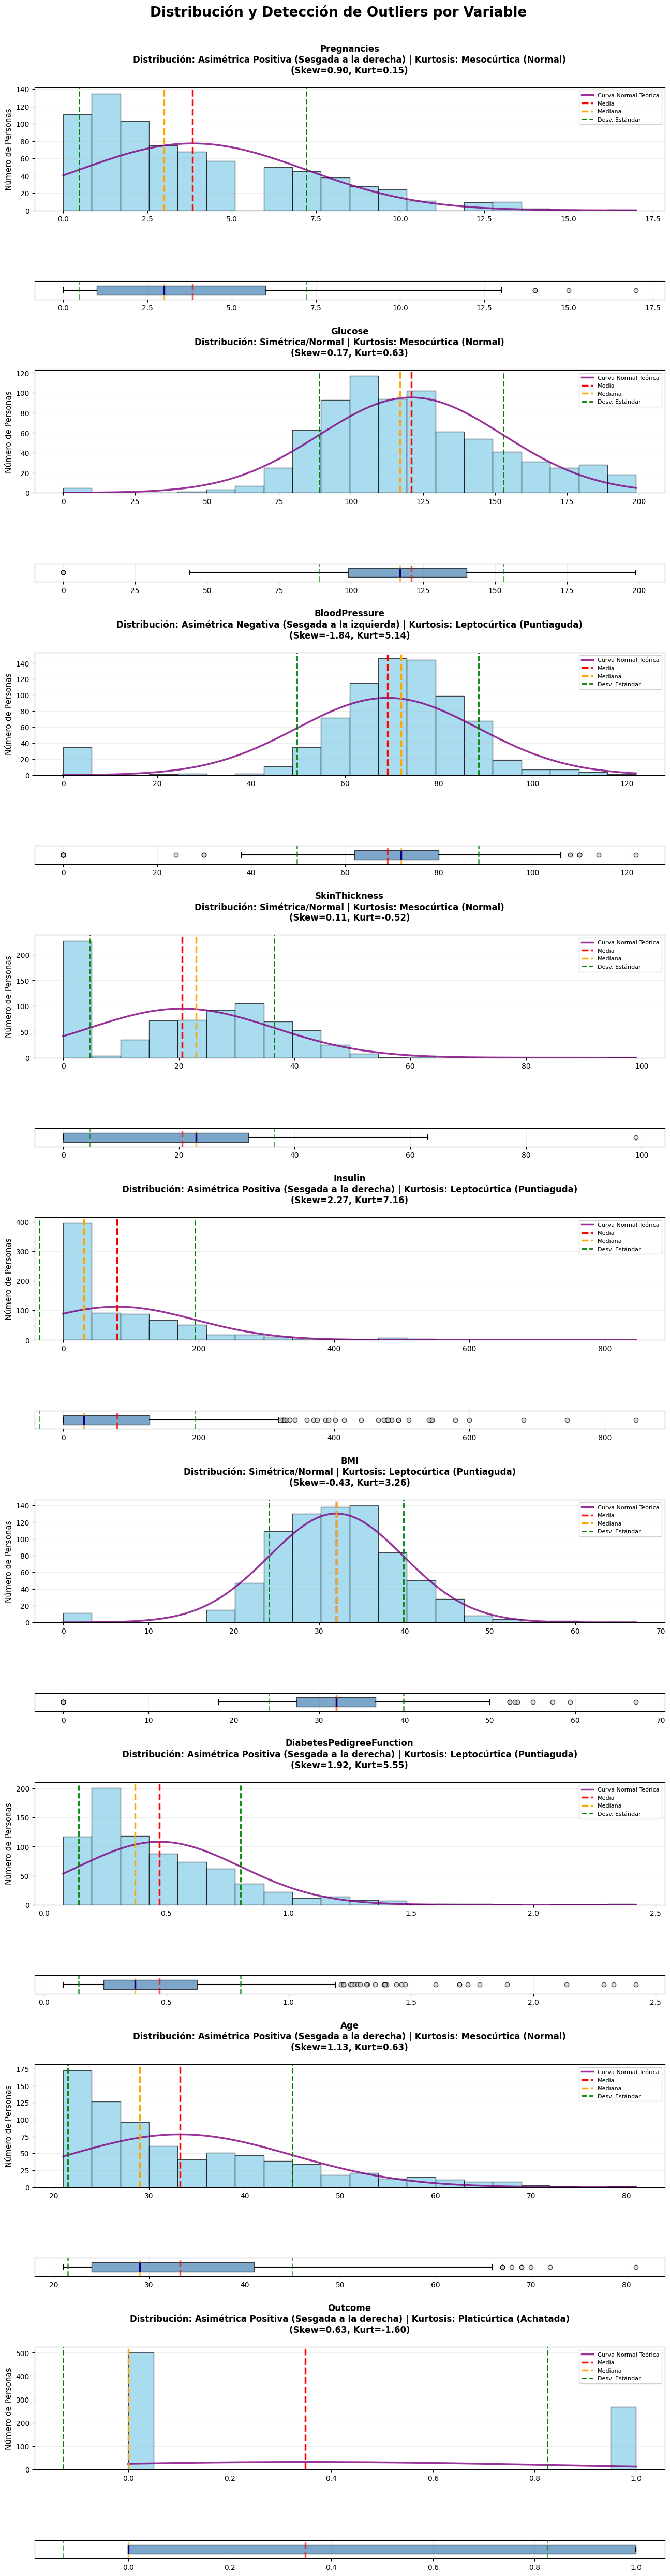

In [8]:
# Histogramas con estadísticas y boxplots
fig = plt.figure(figsize=(14, 50))
gs = fig.add_gridspec(18, 1, hspace=1, height_ratios=[10, 1.5] * 9)

row = 0
for idx, col in enumerate(numerical_cols):
    data = df_original[col].dropna()
    
    # Calcular estadísticas
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skewness = skew(data) 
    kurt = kurtosis(data) 
    
    # Determinar tipo de distribución por skewness
    if abs(skewness) < 0.5:
        dist_type = "Simétrica/Normal"
    elif skewness > 0.5:
        dist_type = "Asimétrica Positiva (Sesgada a la derecha)"
    else:
        dist_type = "Asimétrica Negativa (Sesgada a la izquierda)"
    
    # Determinar tipo de kurtosis
    if kurt > 1:
        kurt_type = "Leptocúrtica (Puntiaguda)"
    elif kurt < -1:
        kurt_type = "Platicúrtica (Achatada)"
    else:
        kurt_type = "Mesocúrtica (Normal)"
    
    # Histograma (fila superior) - CONTEO DE PERSONAS
    ax_hist = fig.add_subplot(gs[row, 0])
    n, bins, patches = ax_hist.hist(data, bins=20, edgecolor='black', alpha=0.7, 
                                      color='skyblue', density=False)
    
    # Superponer curva normal de referencia - ESCALADA AL CONTEO
    x = np.linspace(data.min(), data.max(), 100)
    # Escalar la curva normal para que se ajuste al histograma de conteos
    bin_width = bins[1] - bins[0]  # Ancho de cada barra
    scale_factor = len(data) * bin_width  # Factor de escala
    ax_hist.plot(x, norm.pdf(x, mean_val, std_val) * scale_factor, 
                 color='purple', linewidth=2.5, linestyle='-', 
                 label='Curva Normal Teórica', alpha=0.8)
    
    # Líneas verticales de estadísticas
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, 
                    label=f'Media')
    ax_hist.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, 
                    label=f'Mediana')
    ax_hist.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2, 
                    label=f'Desv. Estándar')
    ax_hist.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2)
    
    # Título con tipo de distribución, skewness y kurtosis
    ax_hist.set_title(f'{col}\nDistribución: {dist_type} | Kurtosis: {kurt_type}\n(Skew={skewness:.2f}, Kurt={kurt:.2f})', 
                      fontsize=12, fontweight='bold', pad=20)
    ax_hist.set_ylabel('Número de Personas', fontsize=11)
    ax_hist.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax_hist.grid(True, alpha=0.2, axis='y')
    
    # Boxplot horizontal (fila inferior)
    ax_box = fig.add_subplot(gs[row + 1, 0])
    bp = ax_box.boxplot(data, vert=False, patch_artist=True, widths=0.5,
                         boxprops=dict(facecolor='steelblue', alpha=0.7, edgecolor='black'),
                         medianprops=dict(color='darkblue', linewidth=2.5),
                         whiskerprops=dict(color='black', linewidth=1.5),
                         capprops=dict(color='black', linewidth=1.5),
                         flierprops=dict(marker='o', markerfacecolor='lightgray', 
                                       markeredgecolor='black', markersize=6, alpha=0.7))
    
    # Proyectar líneas de estadísticas en el boxplot
    ax_box.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
    ax_box.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, alpha=0.7)
    ax_box.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax_box.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2, alpha=0.7)
    
    ax_box.set_xlim(ax_hist.get_xlim())
    ax_box.grid(True, alpha=0.2, axis='x')
    ax_box.tick_params(axis='y', which='both', left=False, labelleft=False)
    ax_box.set_xlabel('')
    
    row += 2

plt.suptitle('Distribución y Detección de Outliers por Variable', 
             fontsize=19, fontweight='bold', y=1.002)
plt.subplots_adjust(top=0.97, bottom=0.015, left=0.08, right=0.95)
plt.show()

# 3 CRIBADO DE VARIABLES 

## 3.1 DFINICIÓN DE OBJETIVO DE ESTUDIO 

### El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

#### En este conjunto de datos encontrarás las siguientes variables:

- Pregnancies. Número de embarazos del paciente (numérico)

- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

- BMI. Índice de masa corporal (numérico)

- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

- Age. Edad del paciente (numérico)

- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

## 3.2 CREACIÓN DE DATASET PARA TRABAJAR

In [9]:
df = df_original.copy()

## 3.3 VERIFICACIÓN DE VALORES ÚNICOS POR CADA COLUMNA Y BÚSQUEDA DE VALORES FALTANTES ENMASCARADOS

In [10]:
print(df['Glucose'].value_counts())

Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64


In [11]:
# Verificar columnas con valores únicos igual a 1
columnas_un_valor = df.nunique()[df.nunique() == 1]

if len(columnas_un_valor) > 0:
    print("="*50)
    print("COLUMNAS CON VALORES ÚNICOS = 1")
    print("="*50)
    print("\n Nombres de las Columnas:")
    print(columnas_un_valor.index.tolist())
    print(f"\n Total de Columnas con un Solo Valor: {len(columnas_un_valor)}")
else:
    print("="*50)
    print("No hay Columnas con Valores Únicos igual a 1")
    print("="*50)

# Análisis de valores únicos por columna
for columna in df.columns: # → Recorre todas las columnas 
    print(f"\n{'='*25}")
    print(f"COLUMNA: {columna}")
    print(f"{'='*25}")
    print(df[columna].value_counts()) # Muestra cada valor único y cuántas veces aparece, ordenado de mayor a menor frecuencia
    print(f"\nTotal de Valores Únicos: {df[columna].nunique()}") # → Cuenta cuántos valores diferentes hay en total  

No hay Columnas con Valores Únicos igual a 1

COLUMNA: Pregnancies
Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64

Total de Valores Únicos: 17

COLUMNA: Glucose
Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64

Total de Valores Únicos: 136

COLUMNA: BloodPressure
BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38 

## 3.4 VERIFICACIÓN DE DATOS FALTANTES EN COLUMNAS

In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 3.5 VERIFICACIÓN DE DATOS FALTANTES EN FILAS > 40%

In [13]:
df_filas_faltantes = (df.T.isnull().sum()* 100 / len(df)).round(2)
if df_filas_faltantes[df_filas_faltantes > 0.40].any():
    print(df_filas_faltantes[df_filas_faltantes > 0.40])
else:
    print("No hay Filas con Valores Faltantes > 40 % en el DataSet")

No hay Filas con Valores Faltantes > 40 % en el DataSet


## 3.6 GRÁFICA DE VALORES FALTANTES 

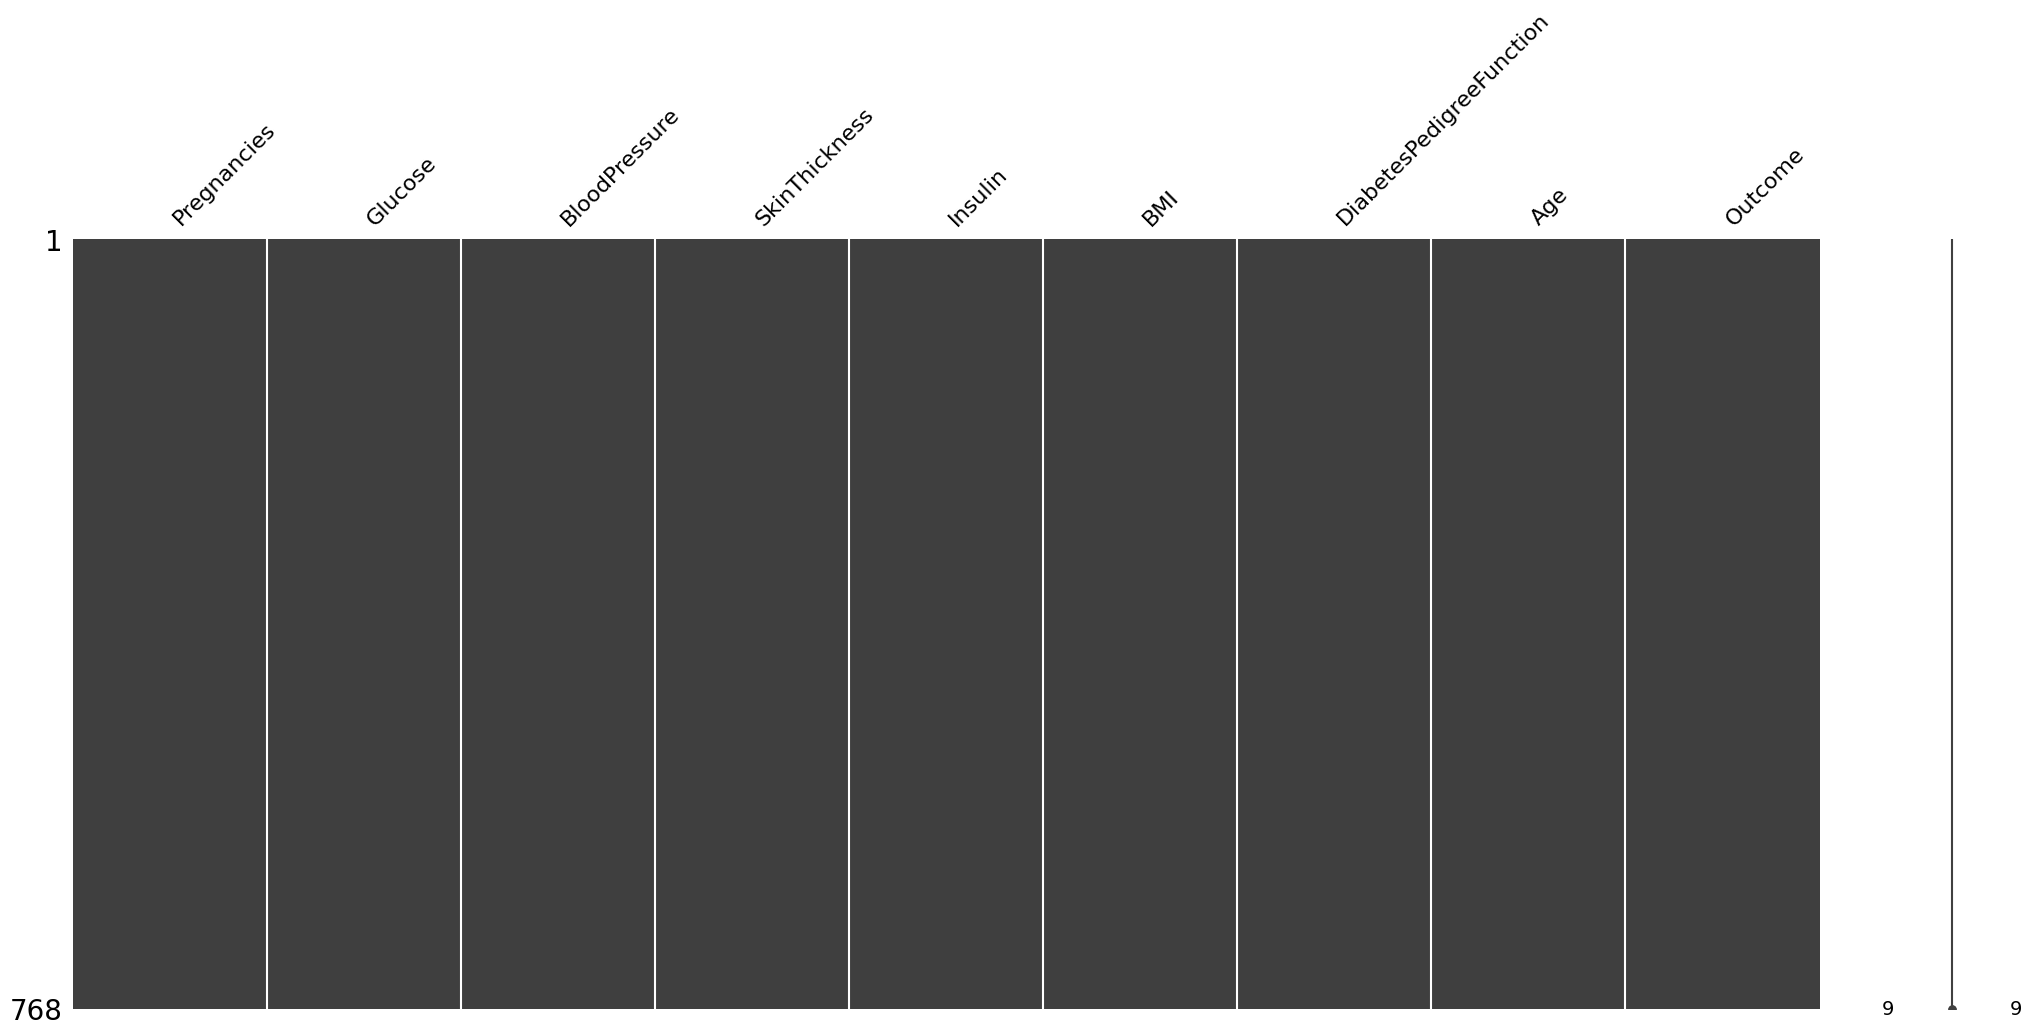

In [14]:
msno.matrix(df)
plt.show()

## 3.7 COMPROBACIÓN DE DATOS DUPLICADOS EN FILAS

In [15]:
filas_duplicadas = df[df.duplicated(keep=False)] # keep=False muestra TODAS las ocurrencias (incluyendo la original)

if len(filas_duplicadas) > 0:
    print(f"Se Encontraron {len(filas_duplicadas)} Filas Duplicadas:")
    print(f"Esto Representa {len(filas_duplicadas)/len(df)*100:.2f}% del DataSet\n")
    print(filas_duplicadas)
else:
    print("No hay Filas Duplicadas en el DataSet")

No hay Filas Duplicadas en el DataSet


## 3.8 COMPROBACIÓN DE DATOS DUPLICADOS EN COLUMNAS CON LA TRANSPUESTA

In [16]:
columnas_duplicadas = df.T.duplicated(keep=False).sum()

if columnas_duplicadas > 0:
    print(f"\nSe Encontraron {columnas_duplicadas} Columnas Duplicadas")
    print("\nNombres de las Columnas Duplicadas:")
    print(df.T[df.T.duplicated(keep=False)].index)
else:
    print("\nNo hay Columnas Duplicadas en el DataSet")


No hay Columnas Duplicadas en el DataSet


## 3.8 DETECCIÓN DE OUTLIERS 

In [17]:
# Lista de columnas que quiero analizar
columnas = [col for col in df.columns]

# Para guardar los resultados
resultados = []

# Analizar cada columna una por una
for columna in columnas:
    
    # Obtener los datos de la columna
    datos = df[columna]
    
    # Calcular Q1 (25%), Q3 (75%) y IQR
    Q1 = datos.quantile(0.25)  # 25% de los datos
    Q3 = datos.quantile(0.75)  # 75% de los datos
    IQR = Q3 - Q1              # Diferencia entre Q3 y Q1
    
    # Calcular límites
    limite_bajo = Q1 - 1.5 * IQR
    limite_alto = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_bajos = (datos < limite_bajo).sum()
    outliers_altos = (datos > limite_alto).sum()
    total_outliers = outliers_bajos + outliers_altos
    
    # Calcular porcentaje
    porcentaje = (total_outliers / len(datos)) * 100
    
    # Guardar en la lista
    resultados.append({
        'Columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Bajo': limite_bajo,
        'Limite_Alto': limite_alto,
        'Total_Outliers': total_outliers,
        'Porcentaje': round(porcentaje, 2)
    })

# Convertir a DataFrame para verlo bonito
df_outliers = pd.DataFrame(resultados)

# Mostrar resultados
print("="*80)
print("ANÁLISIS DE OUTLIERS")
print("="*80)
print(df_outliers)
print("="*80)

# Explicar qué significa
print("\nINTERPRETACIÓN:")
for i in range(len(df_outliers)):
    col = df_outliers.loc[i, 'Columna']
    limite_bajo = df_outliers.loc[i, 'Limite_Bajo']
    limite_alto = df_outliers.loc[i, 'Limite_Alto']
    total = df_outliers.loc[i, 'Total_Outliers']
    pct = df_outliers.loc[i, 'Porcentaje']
    
    print(f"\n{col}:")
    print(f"  - Valores Normales: Entre {limite_bajo:.1f} y {limite_alto:.1f}")
    print(f"  - Outliers Encontrados: {total} ({pct}%)")
    
    if pct < 5:
        print(f"Pocos Outliers, Está Bien")
    elif pct < 10:
        print(f"Algunos Outliers")
    else:
        print(f"Muchos Outliers")
        
print("="*80)
print("\nSUMA DEL TOTAL DE OUTLIERS EN PORCENTAJE:")
print(df_outliers['Porcentaje'].sum())

ANÁLISIS DE OUTLIERS
                    Columna        Q1         Q3       IQR  Limite_Bajo  \
0               Pregnancies   1.00000    6.00000    5.0000       -6.500   
1                   Glucose  99.00000  140.25000   41.2500       37.125   
2             BloodPressure  62.00000   80.00000   18.0000       35.000   
3             SkinThickness   0.00000   32.00000   32.0000      -48.000   
4                   Insulin   0.00000  127.25000  127.2500     -190.875   
5                       BMI  27.30000   36.60000    9.3000       13.350   
6  DiabetesPedigreeFunction   0.24375    0.62625    0.3825       -0.330   
7                       Age  24.00000   41.00000   17.0000       -1.500   
8                   Outcome   0.00000    1.00000    1.0000       -1.500   

   Limite_Alto  Total_Outliers  Porcentaje  
0       13.500               4        0.52  
1      202.125               5        0.65  
2      107.000              45        5.86  
3       80.000               1        0.13  
4  

CONCLUSIÓN: EN LA INSPECCIÓN GENERAL VEMOS QUE LOS GRÁFICOS NOS MUESTRAN KURTOSIS ALTAS EN VARIABLES COMO (BloodPressure, Insulin, BMI, DiabetesPedigreeFunction) INDICANDONOS ASÍ UNA ALERTA DE QUE HAY UN COMPORTAMIENTO EXTRAÑO EN LOS DATOS Y QUE DEBEMOS ESTUDIAR ESTAS VARIABLES MAS A FONDO A VER QUE SUCEDE.

EN EL ESTUDIO DE OUTLIERS CON PERCENTILES (IQR) CALCULAMOS LA CANTIDAD EN PORCENTAJE QUE SIGNIFICAN ESTOS VALORES EXTRAÑOS DENTRO DEL DATASET.

AMBOS VALORES TIENEN RAZÓN PERO EXPRESAN COSAS DIFERENTES! LA KURTOSIS MIDE FORMA Y PESO DE COLAS, MIENTRAS QUE LOS OUTLIERS DEPENDEN DE UN CRITERIO DE CORTE.

## 3.9 TRANSFORMACIÓN DE VARIABLES CON KURTOSIS ALTA

In [18]:
# ESTRATEGIA: Variables con Kurtosis Alta pero Outliers IQR Bajos
# → NO eliminar datos, TRANSFORMAR la variable

print("="*80)
print("TRANSFORMACIÓN DE VARIABLES CON COMPORTAMIENTOS ANÓMALOS")
print("="*80)

# 1. INSULIN - Transformación Logarítmica (maneja ceros automáticamente)
df['Insulin_log'] = np.log1p(df['Insulin'])
print("\nInsulin transformada con log1p (maneja ceros)")
print(f"   Original: min={df['Insulin'].min()}, max={df['Insulin'].max()}")
print(f"   Transformada: min={df['Insulin_log'].min():.2f}, max={df['Insulin_log'].max():.2f}")

# 2. DiabetesPedigreeFunction - Transformación de Raíz Cuadrada (maneja ceros automaticamente, pero es mas útil para reducir asimetrías leves)
df['DiabetesPedigreeFunction_sqrt'] = np.sqrt(df['DiabetesPedigreeFunction'])
print("\nDiabetesPedigreeFunction transformada con raíz cuadrada")
print(f"   Original: min={df['DiabetesPedigreeFunction'].min()}, max={df['DiabetesPedigreeFunction'].max()}")
print(f"   Transformada: min={df['DiabetesPedigreeFunction_sqrt'].min():.2f}, max={df['DiabetesPedigreeFunction_sqrt'].max():.2f}")

# 3. BloodPressure - Detectar y reemplazar ceros (Valor imposible para presión arterial)
ceros_bp = (df['BloodPressure'] == 0).sum()
if ceros_bp > 0:
    df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
    print(f"\nBloodPressure: {ceros_bp} valores 0 reemplazados por nan")
else:
    print("\nBloodPressure: No hay valores 0")

# 4. BMI - Detectar y reemplazar ceros (Valor imposible para indice de masa corporal)
ceros_bmi = (df['BMI'] == 0).sum()
if ceros_bmi > 0:
    df['BMI'] = df['BMI'].replace(0, np.nan)
    print(f"BMI: {ceros_bmi} valores 0 reemplazados por nan")
else:
    print("BMI: No hay valores 0")

# 5. SkinThickness - (Un grosor de 0 mm en el pliegue cutáneo del tríceps no es posible, 
# ya que incluso en los casos más extremos de desnutrición, 
# los valores son muy bajos pero no nulos)
ceros_skin = (df['SkinThickness'] == 0).sum()
if ceros_skin > 0:
    df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
    print(f"SkinThickness: {ceros_skin} valores 0 reemplazados por nan")
else:
    print("SkinThickness: No hay valores 0")

# 6. Glucose - Revisar también (Glucosa = 0 es imposible)
ceros_glucose = (df['Glucose'] == 0).sum()
if ceros_glucose > 0:
    df['Glucose'] = df['Glucose'].replace(0, np.nan)
    print(f"Glucose: {ceros_glucose} valores 0 reemplazados por nan")
else:
    print("Glucose: No hay valores 0")

print("\n" + "="*80)
print("RESUMEN:")
print("  - Variables transformadas con log: Insulin")
print("  - Variables transformadas con sqrt: DiabetesPedigreeFunction")
print("  - Variables con ceros transformados a nan: BloodPressure, BMI, SkinThickness, Glucose")
print("="*80)
print("\nTOTAL DE COLUMNAS DESPUÉS DE TRANSFORMACIONES:")
print(df.columns.to_list())


TRANSFORMACIÓN DE VARIABLES CON COMPORTAMIENTOS ANÓMALOS

Insulin transformada con log1p (maneja ceros)
   Original: min=0, max=846
   Transformada: min=0.00, max=6.74

DiabetesPedigreeFunction transformada con raíz cuadrada
   Original: min=0.078, max=2.42
   Transformada: min=0.28, max=1.56

BloodPressure: 35 valores 0 reemplazados por nan
BMI: 11 valores 0 reemplazados por nan
SkinThickness: 227 valores 0 reemplazados por nan
Glucose: 5 valores 0 reemplazados por nan

RESUMEN:
  - Variables transformadas con log: Insulin
  - Variables transformadas con sqrt: DiabetesPedigreeFunction
  - Variables con ceros transformados a nan: BloodPressure, BMI, SkinThickness, Glucose

TOTAL DE COLUMNAS DESPUÉS DE TRANSFORMACIONES:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Insulin_log', 'DiabetesPedigreeFunction_sqrt']


## 3.10 VERIFICACIÓN DE DATOS FALTANTES LUEGO DE REEMPLAZAR CEROS (VALORES IMPOSIBLES) POR NAN 

In [19]:
df.isnull().sum()*100 / len(df)

Pregnancies                       0.000000
Glucose                           0.651042
BloodPressure                     4.557292
SkinThickness                    29.557292
Insulin                           0.000000
BMI                               1.432292
DiabetesPedigreeFunction          0.000000
Age                               0.000000
Outcome                           0.000000
Insulin_log                       0.000000
DiabetesPedigreeFunction_sqrt     0.000000
dtype: float64

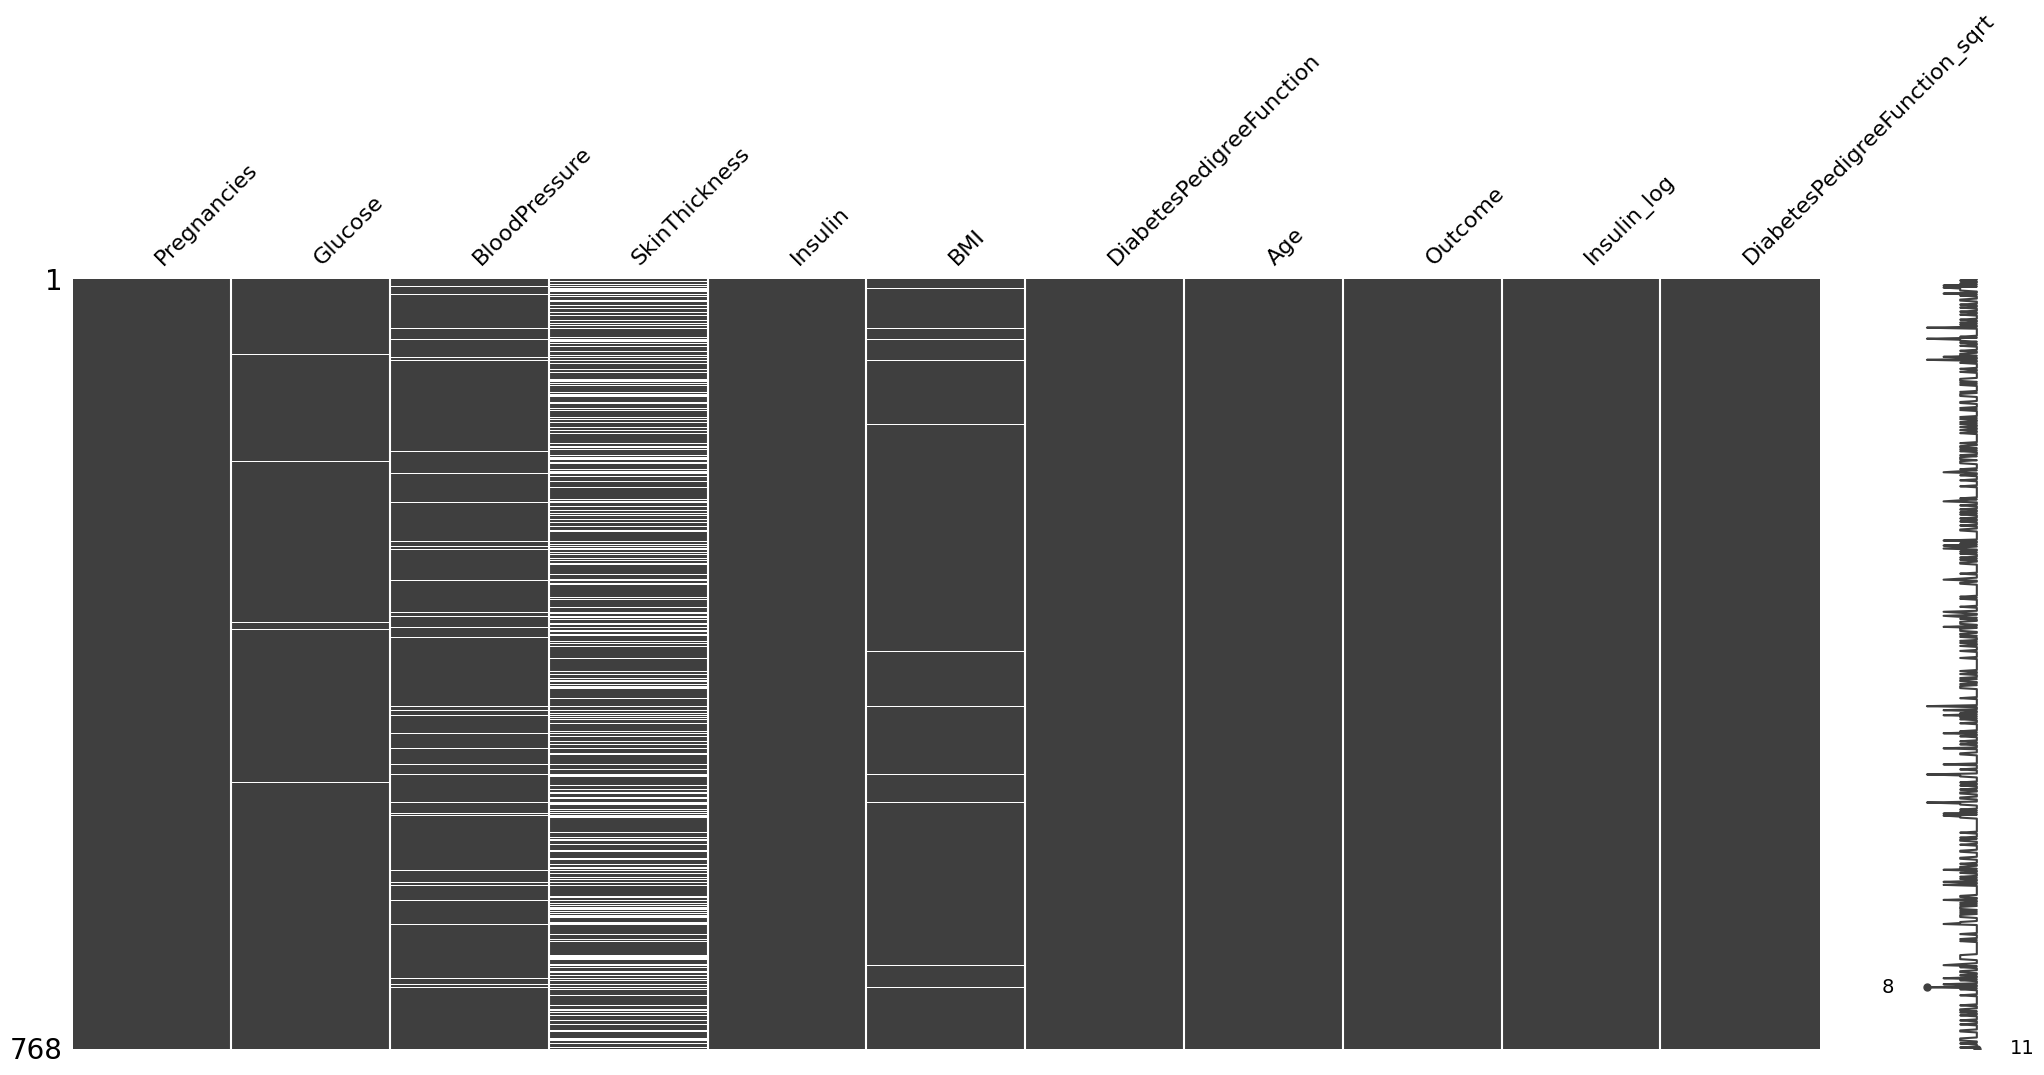

In [20]:
msno.matrix(df)
plt.show()

# 4 DIVISIÓN DATASET TRAIN-TEST 

In [21]:
# PASO 1: Preparar X e Y
X = df.drop('Outcome',axis=1)
Y = df['Outcome']

# PASO 2: Reemplazar -1 con NaN ANTES de dividir
# X = X.replace(-1, np.nan) ## Este paso es importante para que los -1 no afecten el entrenamiento del modelo 
# solo se aplica cuando se ha realizado codificación categorica previamente ya que asume que los nan son -1

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")
print(f"\n Valores nulos en train antes de imputar:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(f"\n Valores nulos en test antes de imputar:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Tamaño del conjunto de entrenamiento: (614, 10)
Tamaño del conjunto de prueba: (154, 10)

 Valores nulos en train antes de imputar:
Glucose            5
BloodPressure     24
SkinThickness    176
BMI                7
dtype: int64

 Valores nulos en test antes de imputar:
BloodPressure    11
SkinThickness    51
BMI               4
dtype: int64


# 5 IMPUTACIÓN DE VALORES FALTANTES 

In [23]:
# Aplicar SimpleImputer SOLO en train (todas las variables son numéricas)
print("Imputando valores faltantes con la mediana del conjunto de entrenamiento...")

# Crear el imputador con estrategia 'median' (robusta a outliers)
imputer = SimpleImputer(strategy='median')

# Fit en train y transformar train
X_train_imputado = imputer.fit_transform(X_train)  # Aprende SOLO de train

# Convertir de vuelta a DataFrame
X_train_imputado = pd.DataFrame(
    X_train_imputado, 
    columns=X_train.columns, 
    index=X_train.index
)

print("\nImputación de entrenamiento completada!")
print(f"Valores nulos en train después de imputar: {X_train_imputado.isnull().sum().sum()}")

# Transformar test usando las medianas aprendidas de train
X_test_imputado = imputer.transform(X_test)  # Solo transform, NO fit

# Convertir de vuelta a DataFrame
X_test_imputado = pd.DataFrame(
    X_test_imputado, 
    columns=X_test.columns, 
    index=X_test.index
)

print(f"Valores nulos en test después de imputar: {X_test_imputado.isnull().sum().sum()}")

Imputando valores faltantes con la mediana del conjunto de entrenamiento...

Imputación de entrenamiento completada!
Valores nulos en train después de imputar: 0
Valores nulos en test después de imputar: 0


### ¿Cuándo usar MissForest?

- Cuando tienes variables categóricas Y numéricas mezcladas

- Cuando el porcentaje de valores faltantes es muy alto (>60%)

- Cuando las variables tienen relaciones complejas entre sí

# 6 VERIFICACIÓN DE OUTLIERS DESPUÉS DE IMPUTAR 

In [24]:
iso = IsolationForest(random_state=123)
df_num = X_train_imputado.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_imputado)

In [25]:
df_num['outlier_flag'].value_counts(normalize=True)*100

outlier_flag
 1    86.644951
-1    13.355049
Name: proportion, dtype: float64

# 7 COMPARACIÓN DE OUTLIERS ANTES Y DESPUÉS DE IMPUTAR 

In [26]:
# Función para detectar outliers con IQR por fila
def detectar_outliers_iqr_por_fila(df):
    """Marca cada fila que tiene al menos 1 outlier en cualquier variable"""
    outlier_mask = pd.Series(False, index=df.index)
    
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_bajo = Q1 - 1.5 * IQR
        limite_alto = Q3 + 1.5 * IQR
        
        # Marcar filas con outliers (ignora NaN)
        col_outliers = (df[col] < limite_bajo) | (df[col] > limite_alto)
        outlier_mask = outlier_mask | col_outliers
    
    return outlier_mask

print("Función detectar_outliers_iqr_por_fila() creada exitosamente ✅")

Función detectar_outliers_iqr_por_fila() creada exitosamente ✅


In [27]:
# 1. Outliers ANTES (IQR)
outliers_antes = detectar_outliers_iqr_por_fila(X_train)

# 2. Outliers DESPUÉS (IsolationForest)
iso = IsolationForest(random_state=123, contamination=0.1)
outliers_despues = (iso.fit_predict(X_train_imputado) == -1)

# 3. Comparación
comparacion = pd.DataFrame({
    'Antes_IQR': outliers_antes.astype(int),
    'Despues_ISO': outliers_despues.astype(int)
})

# 4. Tabla cruzada
print(pd.crosstab(comparacion['Antes_IQR'], comparacion['Despues_ISO'], 
                   rownames=['IQR'], colnames=['IsolationForest'], margins=True))

# 5. Concordancia
concordancia = (comparacion['Antes_IQR'] == comparacion['Despues_ISO']).mean() * 100
print(f"\n✅ Concordancia: {concordancia:.1f}%")

IsolationForest    0   1  All
IQR                          
0                517  17  534
1                 35  45   80
All              552  62  614

✅ Concordancia: 91.5%
